In [1]:
import ast
import matplotlib.pyplot as plt
import pandas as pd 
from datasets import load_dataset
dataset=load_dataset('lukebarousse/data_jobs')
df=dataset['train'].to_pandas()
df['job_posted_date']=pd.to_datetime(df['job_posted_date'])
df['job_skills']=df['job_skills'].apply(lambda x:ast.literal_eval(x) if pd.notna(x) else x)
df_DA=df[df['job_title_short']=='Data Analyst'].copy()

In [2]:
df_DA_US=df_DA[df_DA['job_country']=='United States']

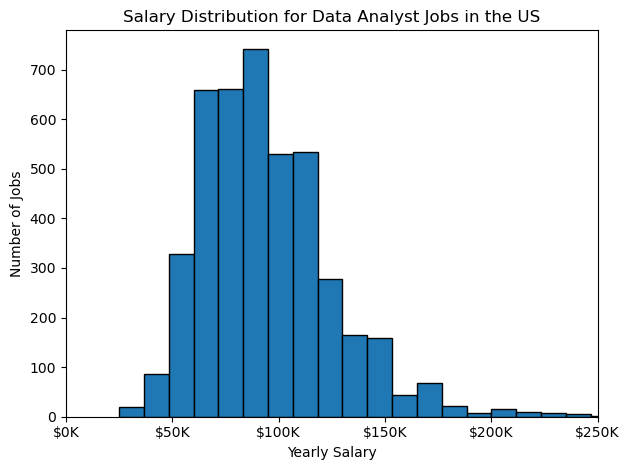

In [14]:
from matplotlib.ticker import FuncFormatter
ax=df_DA_US['salary_year_avg'].plot(kind='hist',bins=30,edgecolor='black')
plt.xlim(0,250000)
ax.xaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f'${int(x/1000)}K')
)

plt.xlabel('Yearly Salary')
plt.ylabel('Number of Jobs')
plt.title('Salary Distribution for Data Analyst Jobs in the US')

plt.tight_layout()
plt.show()